In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [5]:
data={
  "x": [10, 0, 5, 6, 3],
   "y":[6,7,4,2,3]
}

In [6]:
df=pd.DataFrame(data)
df

,x,y
0,10,6
1,0,7
2,5,4
3,6,2
4,3,3


In [7]:
x = df[["x"]].values
y = df["y"].values

In [8]:
def likelihood(a, b, sigma=1.0):
    pred = a * x[:, 0] + b
    error = y - pred
    return -np.sum(error**2) / (2 *  sigma**2) 

In [9]:
def metropolis(iterations=10000, step=0.1):
    a, b = 0.0, 0.0
    current_score = likelihood(a, b)

    samples = []

    for _ in range(iterations):

        a_new = a + np.random.normal(0, step)
        b_new = b + np.random.normal(0, step)

        new_score = likelihood(a_new, b_new)
        
        acceptance = min(1, np.exp(new_score - current_score))

        if np.random.rand() < acceptance:
            a, b = a_new, b_new
            current_score = new_score

        samples.append((a, b))

    return np.array(samples)


In [10]:
samples = metropolis(iterations=10000)
samples

array([[ 0.00000000e+00,  0.00000000e+00],
       [ 8.89599370e-02, -1.39385755e-01],
       [ 1.40598970e-01, -5.37049564e-02],
       ...,
       [ 3.69805598e-03,  4.58959999e+00],
       [ 3.69805598e-03,  4.58959999e+00],
       [ 3.69805598e-03,  4.58959999e+00]], shape=(10000, 2))

In [11]:
burn_in = 2000
samples_post = samples[burn_in:]

a_mean = np.mean(samples_post[:, 0])
b_mean = np.mean(samples_post[:, 1])

print(f"Estimated a: {a_mean:.4f}")
print(f"Estimated b: {b_mean:.4f}")

Estimated a: -0.0670
Estimated b: 4.6949


In [12]:
print("\nPredictions:")
for i in range(len(x)):
    y_pred = a_mean * x[i][0] + b_mean
    print(f"x: {x[i][0]} | y_true: {y[i]} | y_pred: {y_pred:.2f}")


Predictions:
x: 10 | y_true: 6 | y_pred: 4.03
x: 0 | y_true: 7 | y_pred: 4.69
x: 5 | y_true: 4 | y_pred: 4.36
x: 6 | y_true: 2 | y_pred: 4.29
x: 3 | y_true: 3 | y_pred: 4.49


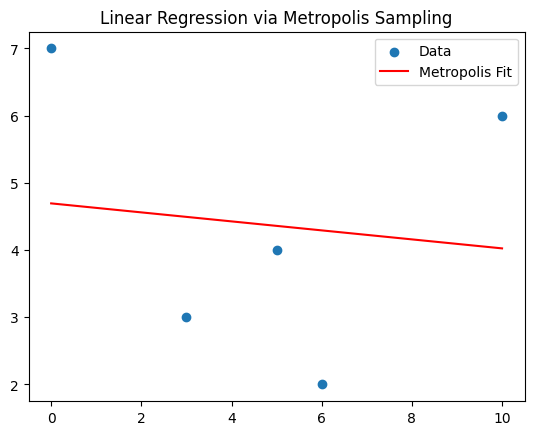

In [13]:
plt.scatter(x, y, label="Data")

x_line = np.linspace(min(x), max(x), 100)
y_line = a_mean * x_line + b_mean

plt.plot(x_line, y_line, color="red", label="Metropolis Fit")
plt.legend()
plt.title("Linear Regression via Metropolis Sampling")
plt.show()

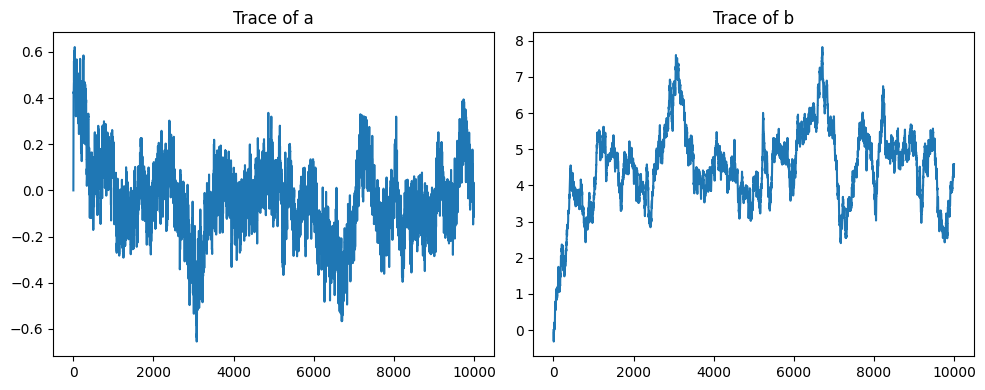

In [14]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(samples[:,0])
plt.title("Trace of a")

plt.subplot(1,2,2)
plt.plot(samples[:,1])
plt.title("Trace of b")

plt.tight_layout()
plt.show()